# Predicción de O3

## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

## Archivo

In [4]:
df = pd.read_csv(
    "contaminantes/contaminantes_2026_nuevo.csv",
    skiprows=9
)

df.head()

,date,id_station,id_parameter,valor,unit
0,2026-01-01 00:00:00,ACO,CO,NaN,15
1,2026-01-01 00:00:00,ACO,NO,NaN,1
2,2026-01-01 00:00:00,ACO,NO2,NaN,1
3,2026-01-01 00:00:00,ACO,NOX,NaN,1
4,2026-01-01 00:00:00,ACO,O3,NaN,1


## Preparación de datos

In [5]:
df['date'] = pd.to_datetime(df['date'])

station = 'MER'
contaminantes = ['O3', 'NO', 'NO2', 'NOX', 'CO']

df_mer = df[
    (df['id_station'] == station) &
    (df['id_parameter'].isin(contaminantes))
].copy()

df_model = df_mer.pivot_table(
    index='date',
    columns='id_parameter',
    values='valor',
    aggfunc='mean'
)

df_model = df_model.dropna().sort_index()

print('Observaciones completas:', df_model.shape[0])
df_model.head()

Observaciones completas: 4639


id_parameter,CO,NO,NO2,NOX,O3
date,,,,,
2026-01-01 00:00:00,1.05,7.0,41.0,47.0,7.0
2026-01-01 01:00:00,1.31,13.0,45.0,58.0,3.0
2026-01-01 02:00:00,1.63,27.0,48.0,76.0,3.0
2026-01-01 03:00:00,1.43,35.0,44.0,79.0,3.0
2026-01-01 04:00:00,1.22,12.0,44.0,56.0,4.0


## Regresión lineal para predecir O3

In [6]:
X = df_model[['NO', 'NO2', 'NOX', 'CO']]
y = df_model['O3']

X_const = sm.add_constant(X)

modelo = sm.OLS(y, X_const).fit()

print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                     O3   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     394.8
Date:                Mon, 28 Sep 2026   Prob (F-statistic):          4.76e-293
Time:                        16:38:45   Log-Likelihood:                -21912.
No. Observations:                4639   AIC:                         4.383e+04
Df Residuals:                    4634   BIC:                         4.387e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         56.3540      1.066     52.853      0.0

## R<sup>2</sup>, coeficientes y p-values

In [7]:
print(f'R² = {modelo.rsquared:.4f}')

resultados = pd.DataFrame({
    'Coeficiente': modelo.params,
    'p-value': modelo.pvalues
})

resultados

R² = 0.2542


,Coeficiente,p-value
const,56.354044,0.000000e+00
NO,1.208539,1.264881e-01
NO2,0.687055,3.855172e-01
NOX,-1.541916,5.127578e-02
CO,14.294903,5.704032e-12


## VIF de cada variable

In [8]:
X_vif = sm.add_constant(df_model[['NO', 'NO2', 'NOX', 'CO']])

vif = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

vif

,Variable,VIF
0,const,7.103834
1,NO,5063.595655
2,NO2,871.942799
3,NOX,8104.930265
4,CO,5.606601


## Residuos vs predichos

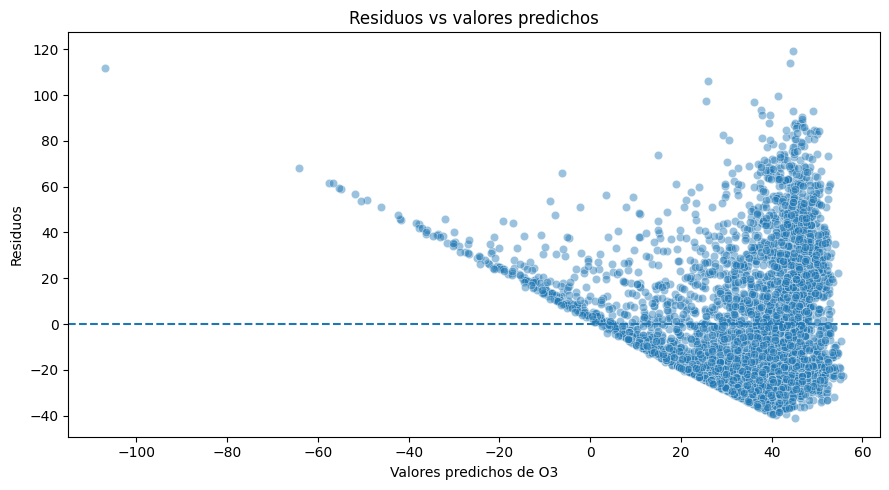

In [9]:
df_model['Predicho'] = modelo.fittedvalues
df_model['Residuo'] = modelo.resid

plt.figure(figsize=(9, 5))
sns.scatterplot(
    x=df_model['Predicho'],
    y=df_model['Residuo'],
    alpha=0.45
)
plt.axhline(0, linestyle='--')
plt.xlabel('Valores predichos de O3')
plt.ylabel('Residuos')
plt.title('Residuos vs valores predichos')
plt.tight_layout()
plt.show()

## Breusch–Pagan

In [10]:
bp_test = het_breuschpagan(modelo.resid, modelo.model.exog)

bp_resultados = pd.Series(
    bp_test,
    index=['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
)

bp_resultados

LM Statistic    9.146962e+01
LM p-value      6.416021e-19
F Statistic     2.330222e+01
F p-value       4.265777e-19
dtype: float64

## Residuos en el tiempo y promedio por hora

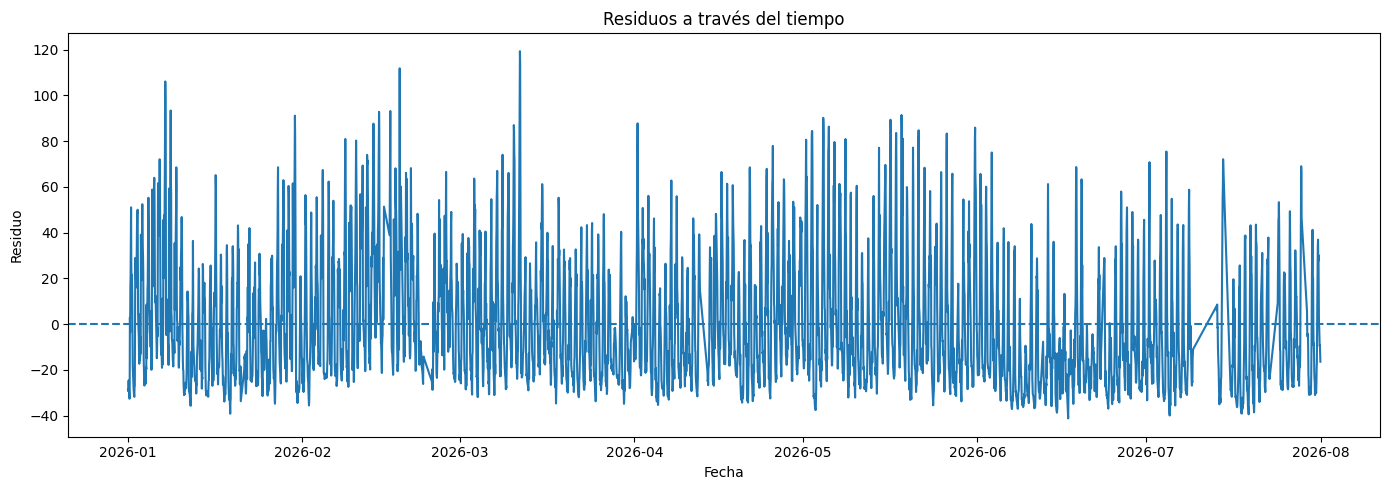

In [11]:
plt.figure(figsize=(14, 5))
plt.plot(df_model.index, df_model['Residuo'])
plt.axhline(0, linestyle='--')
plt.xlabel('Fecha')
plt.ylabel('Residuo')
plt.title('Residuos a través del tiempo')
plt.tight_layout()
plt.show()

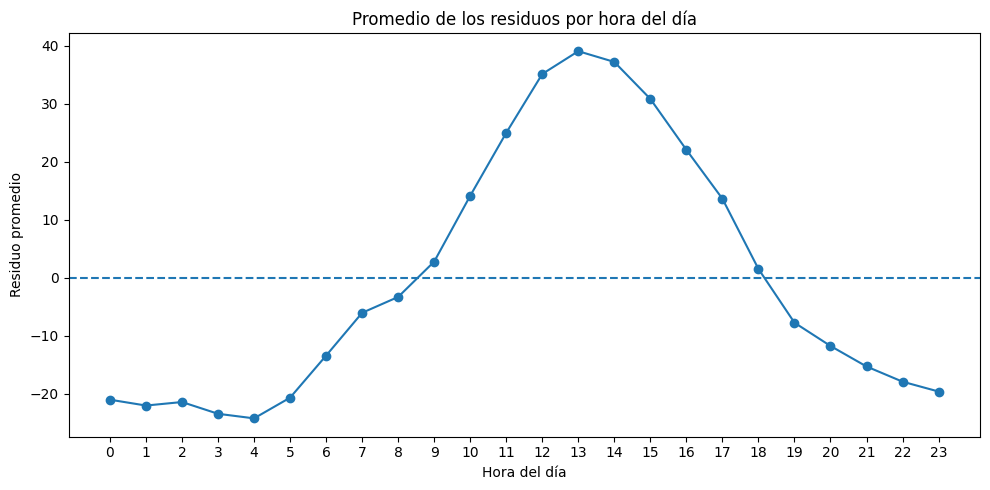

In [12]:
df_model['Hora'] = df_model.index.hour

residuos_hora = df_model.groupby('Hora')['Residuo'].mean()

plt.figure(figsize=(10, 5))
plt.plot(residuos_hora.index, residuos_hora.values, marker='o')
plt.axhline(0, linestyle='--')
plt.xticks(range(24))
plt.xlabel('Hora del día')
plt.ylabel('Residuo promedio')
plt.title('Promedio de los residuos por hora del día')
plt.tight_layout()
plt.show()

## Durbin–Watson

In [13]:
dw = durbin_watson(modelo.resid)
print(f'Durbin-Watson = {dw:.4f}')

Durbin-Watson = 0.1939


## QQ-plot de los residuos

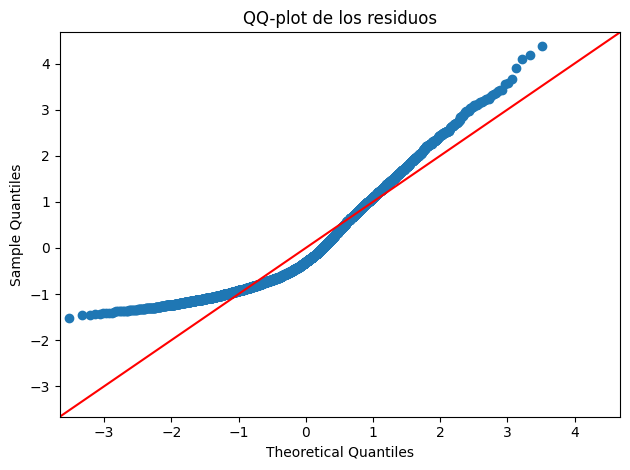

In [14]:
sm.qqplot(modelo.resid, line='45', fit=True)
plt.title('QQ-plot de los residuos')
plt.tight_layout()
plt.show()

## Conclusiones

¿Qué supuestos se rompen? ¿Le creen al coeficiente de NO2 y a su p-value?

Hay varios puntos importantes que se muestran en la regresión lineal, o supuestos que se rompen. Uno de ellos es la multicolinealidad entre NO, NO2 y NOX, ya que tienen valoers muy altos de VIF. Esto ocurre porque NOX está firmado por la combinación de NO y NO2. En la prueba de Breusch–Pagan se muestra un p-value menos a 0.05, lo que indica heterocedasticidad en los residuos. DUrbin-Watson, al estar muy alejado de 2, es evidencia de una fuerte autocorrelación positiva de los errores debido a la naturaleza temporal de las observaciones. Finalmente, el QQ-plot permite observar desviaciones respecto al supuesto de normalidad. Por estas razones, no conviene interpretar de manera aislada el coeficiente de NO2 ni confiar plenamente en su p-value. La multicolinealidad hace inestables los coeficientes y sus errores estándar, mientras que la heterocedasticidad y la autocorrelación hacen que los errores estándar convencionales de OLS y, por lo tanto, sus p-values, puedan ser poco confiables.